In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Dec 2023

@author: Rodrigo Pena
"""
!pip install brian2
from brian2 import *
seed(111)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.1 MB/s eta 0:00:00


In [2]:
def fixed_indegree(indegree,n_post_pop,n_pre_pop):
    np.random.seed(10)
    presyn_indices = np.zeros([n_post_pop*indegree])
    postsyn_indices = np.zeros([n_post_pop*indegree])
    counter = 0

    for post in range(n_post_pop):
        x = np.arange(0, n_pre_pop)
        y = np.random.permutation(x)
        for i in range(indegree):
            presyn_indices[counter] = y[i]
            postsyn_indices[counter] = post
            counter += 1
    presyn_indices = presyn_indices.astype(int)
    postsyn_indices = postsyn_indices.astype(int)
    return presyn_indices, postsyn_indices

In [ ]:
def simulation(tf,orien,pope_pref1 = 10, pope_pref2 = 10, pope_pref3 = 10, pope_pref4 = 10,
               popi_pref1 = 90, popi_pref2 = 10, popi_pref3 = 10, popi_pref4 = 10, pl=0,
               size_orientation=30):

  #size_orientation1=30, sizesize_orientation2=30,size_orientation3=30,size_orientation4=30):

    seed(10)
    #net parameters
    NE = 4000
    gamma = 0.2
    NI = int(gamma*NE)
    CE = int(NE*0.2)
    CI = int(gamma*CE)
    tau = 20*ms #time constant
    tref = 2*ms
    vth = 20
    vr = 0
    J = 0.1
    g = 8
    D = 3*ms
    #sigma_noise = 0.1 #standard deviation of noise

    eqs = '''
    dv/dt = (-v + I + sigma_noise * xi * sqrt(dt)) / tau : 1 (unless refractory)
    I = current_amplitude * cos((pi/180)*(stimulus_orientation - preferred_orientation)) * exp(-0.5 * ((stimulus_orientation - preferred_orientation) / orientation_tuning_width)**2) : 1
    preferred_orientation : 1
    current_amplitude : 1 (shared)
    stimulus_orientation : 1 (shared)
    orientation_tuning_width : 1 (shared)
    sigma_noise : 1  # Noise standard deviation (dimensionless)


   #eqs='''
   #     dv/dt = (-v + I) / tau : 1 (unless refractory)
   ####   preferred_orientation : 1
       # current_amplitude : 1 (shared)
       # stimulus_orientation : 1 (shared)
       # orientation_tuning_width : 1 (shared)
       ## sigma_noise : 1
       # '''

        # orientation_tuning_width : 1 (shared)

    #neurons

    neurons = NeuronGroup(NE+NI,eqs,method='euler',dt=0.01*ms,threshold='v>=vth',reset='v=vr',refractory=tref)
    neurons.v = 'rand()*(vth-vr) + vr'
    #pop_alle = neurons[:NE]
    #pop_e1 = neurons[:999] #[:NE]
    #pop_e2 = neurons[1000:1999]
    #pop_e3 = neurons[2000:2999]
    #pop_e4 = neurons[3000:NE]
    #pop_alli = neurons[NE:(NE+NI)]
    #pop_i1 = neurons[4000:4199]
    #pop_i2 = neurons[4200:4399]
    #pop_i3 = neurons[4400:4599]
    #pop_i4 = neurons[4600:]

    #decrease 1st pop (700,exc),
   # pop_e1 = neurons[:1099] #[:NE]
   # pop_e2 = neurons[1100:2199]
   # pop_e3 = neurons[2200:2299]#1100
   # pop_e4 = neurons[2300:NE]
   # pop_i1 = neurons[4000:4219] #140
   # pop_i2 = neurons[4220:4439]
   # pop_i3 = neurons[4440:4659]#220
   # pop_i4 = neurons[4660:]

   # neurons[:1099].preferred_orientation = pope_pref1
   # neurons[1100:2199].preferred_orientation = pope_pref2
   # neurons[2200:2299].preferred_orientation = pope_pref3
   # neurons[2300:NE].preferred_orientation = pope_pref4 # Preferred orientation in degrees

    #pop_i1 = neurons[4000:4219].preferred_orientation = popi_pref1
    #pop_i2 = neurons[4220:4439].preferred_orientation = popi_pref2
    #pop_i3 = neurons[4440:4659].preferred_orientation = popi_pref3
    #pop_i4 = neurons[4660:].preferred_orientation = popi_pref4


  #original
    pop_alle = neurons[:NE]
    pop_e1 = neurons[:1000] #[:NE]
    pop_e2 = neurons[1000:2000]
    pop_e3 = neurons[2000:3000]
    pop_e4 = neurons[3000:NE]
    pop_alli = neurons[NE:(NE+NI)]
    pop_i1 = neurons[4000:4200]
    pop_i2 = neurons[4200:4400]
    pop_i3 = neurons[4400:4600]
    pop_i4 = neurons[4600:]

    # # Set up orientation-selective current

    neurons[:1000].preferred_orientation = pope_pref1
    neurons[1000:2000].preferred_orientation = pope_pref2
    neurons[2000:3000].preferred_orientation = pope_pref3
    neurons[3000:NE].preferred_orientation = pope_pref4 # Preferred orientation in degrees

    neurons[4000:4200].preferred_orientation = popi_pref1
    neurons[4200:4400].preferred_orientation = popi_pref2
    neurons[4400:4600].preferred_orientation = popi_pref3
    neurons[4600:].preferred_orientation = popi_pref4

    # # Set up orientation-selective current
    #---
    #neurons[NE:(NE+NI)].preferred_orientation = popi_pref  # Preferred orientation in degrees
    neurons.stimulus_orientation = orien  # Stimulus orientation in degrees
    # Generate cosine-tuned current profile
    neurons.current_amplitude = 50
    neurons.orientation_tuning_width = size_orientation

    #Poisson
    P = PoissonInput(neurons, 'v', NE+NI, 1*Hz, weight=2*J)

    #E indexes
    presyn_indices,postsyn_indices=fixed_indegree(CE,(NE+NI),NE)
    con_e = Synapses(pop_alle, neurons, on_pre='v += J', delay=D,dt=0.01*ms)
    con_e.connect(i=presyn_indices,j=postsyn_indices)

    #I indexes
    presyn_indices,postsyn_indices=fixed_indegree(CI,(NE+NI),NI)
    con_i = Synapses(pop_alli, neurons, on_pre='v -= J*g', delay=D,dt=0.01*ms)
    con_i.connect(i=presyn_indices,j=postsyn_indices)


    ratemon = PopulationRateMonitor(neurons)
    spkmon = SpikeMonitor(neurons)

    net = Network(neurons, pop_alle, pop_alli, con_e, con_i, P, spkmon, ratemon)
    net.run(tf,'stdout')

    if(pl==1):

        subplot(2,1,1)
        plot(spkmon.t/ms,spkmon.i,'k.',markersize=0.5)
        # ylim(950,1000)
        xlim(1000,1800)

        subplot(2,1,2)
        plot(ratemon.t/ms, ratemon.rate/Hz)
        xlim(1000,1800)
        show()

    return spkmon, ratemon

## Normalizing data to new range of (5,40,5)

Original but with slight modification

In [ ]:
import random

trial = 1
rr = np.arange(1,180,22.5)
individual_rates = np.zeros((len(rr),4799))
count=0

seed(10)
for k in range(trial):
  mfr = [] #mean firing rate
  tf=200*ms
  #for i in rr:
   #   spks,rate = simulation(tf=tf,orien=120,pope_pref1=120,pope_pref2=0,pope_pref3=90,pope_pref4=0,
  #                                           popi_pref1=0,popi_pref2=90,popi_pref3=150,popi_pref4=30,pl=0,size_orientation=i)

  orienRan = random.randint(1,180)
  E1 = random.randint(1, 180)
  E2 = random.randint(1, 180)
  E3 = random.randint(1, 180)
  E4 = random.randint(1, 180)
  I1 = random.randint(1, 180)
  I2 = random.randint(1, 180)
  I3 = random.randint(1, 180)
  I4 = random.randint(1, 180)

  print(orienRan)
  print(E1)
  print(E2)
  print(E3)
  print(E4)
  print(I1)
  print(I2)
  print(I3)
  print(I4)

  for i in rr:
    spks,rate = simulation(tf=tf,orien=orienRan,pope_pref1=E1,pope_pref2=E2,pope_pref3=E3,pope_pref4=E4,
                                              popi_pref1=I1,popi_pref2=I2,popi_pref3=I3,popi_pref4=I4,pl=0,size_orientation=i)
    mfr.append(mean(spks.count)/tf)
    a = spks.t/ms
    b = spks.i
    for k in range(np.max(b)):
      aux = a[where(b==k)[0]]
      individual_rates[count,k] = len(aux)/1.0
    count = count + 1

44
69
163
153
21
29
64
26
159
Starting simulation at t=0. s for a duration of 200. ms
199.71 ms (99%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
190.67 ms (95%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 8s
Starting simulation at t=0. s for a duration of 200. ms
189.2 ms (94%) simulated in 10s, estimated 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
200. ms (100%) simulated in 9s
Starting simulation at t=0. s for a duration of 200. ms
195.75 ms (97%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
192.05 ms (96%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
168

In [ ]:
import random

trial = 1
rr = np.arange(1,180,22.5)
individual_rates = np.zeros((len(rr),4799))
count=0

seed(10)
for k in range(trial):
  mfr = [] #mean firing rate
  tf=200*ms
  for i in rr:
      spks,rate = simulation(tf=tf,orien=120,pope_pref1=120,pope_pref2=0,pope_pref3=90,pope_pref4=0,
                                             popi_pref1=0,popi_pref2=90,popi_pref3=150,popi_pref4=30,pl=0,size_orientation=i)

      mfr.append(mean(spks.count)/tf)
      a = spks.t/ms
      b = spks.i
      for k in range(np.max(b)):
        aux = a[where(b==k)[0]]
        individual_rates[count,k] = len(aux)/1.0
      count = count + 1

Starting simulation at t=0. s for a duration of 200. ms
196.96 ms (98%) simulated in 10s, estimated < 1s remaining.


WARNING    neurongroup_2's variable 'v' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]
WARNING    neurongroup_2_subgroup's variable 'v' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]
WARNING    neurongroup_2_subgroup_5's variable 'v' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]


200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
194.58 ms (97%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
161.55 ms (80%) simulated in 10s, estimated 2s remaining.
200. ms (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 200. ms
194.46 ms (97%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
193.48 ms (96%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
169.67 ms (84%) simulated in 10s, estimated 2s remaining.
200. ms (100%) simulated in 12s
Starting simulation at t=0. s for a duration of 200. ms
194.59 ms (97%) simulated in 10s, estimated < 1s remaining.
200. ms (100%) simulated in 10s
Starting simulation at t=0. s for a duration of 200. ms
152.8 ms (76%) simulated in 

In [ ]:
rr = np.linspace(1,180,8)  # Create 8 values between 1 and 180

# Normalize the x-values (size_orientation) from (1, 180) to (5, 40)
x_min, x_max = 1, 180
y_min, y_max = 5, 40
normalized_rr = y_min + ((rr - x_min) * (y_max - y_min)) / (x_max - x_min)

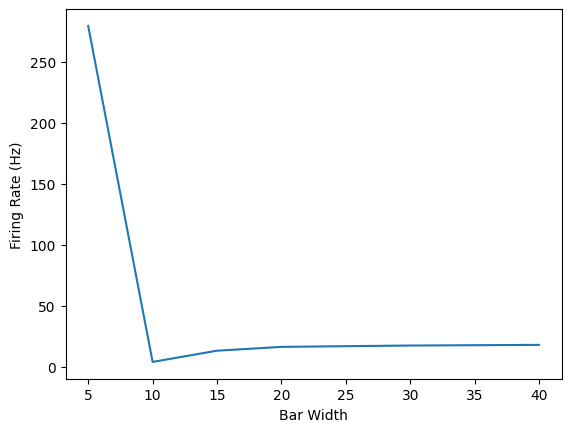

In [ ]:
# Plotting with normalized x-values
plt.plot(normalized_rr, mfr, '-')
plt.xticks(np.arange(5, 45, 5))  # Updated ticks for the new x-range (5, 40, 5)
plt.xlabel("Bar Width")
plt.ylabel("Firing Rate (Hz)")
plt.show()

In [ ]:
individual_rates

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       ...,
       [1., 0., 1., ..., 1., 1., 1.],
       [1., 0., 0., ..., 2., 2., 0.],
       [1., 1., 0., ..., 2., 2., 0.]])

### Finding highest response in each neuron and Size that created it

In [ ]:
# Find highest response in each neuron and the size_orientation that produced it
highest_responses = []
corresponding_sizes = []

for neuron in range(individual_rates.shape[1]):  # Loop over each neuron (columns)
    max_response = max(individual_rates[:, neuron])  # Find max response for this neuron
    max_response_idx = individual_rates[:, neuron].argmax()  # Get index of the max response
    corresponding_size = normalized_rr[max_response_idx]  # Get the size that produced the max response

    highest_responses.append(max_response)
    corresponding_sizes.append(corresponding_size)

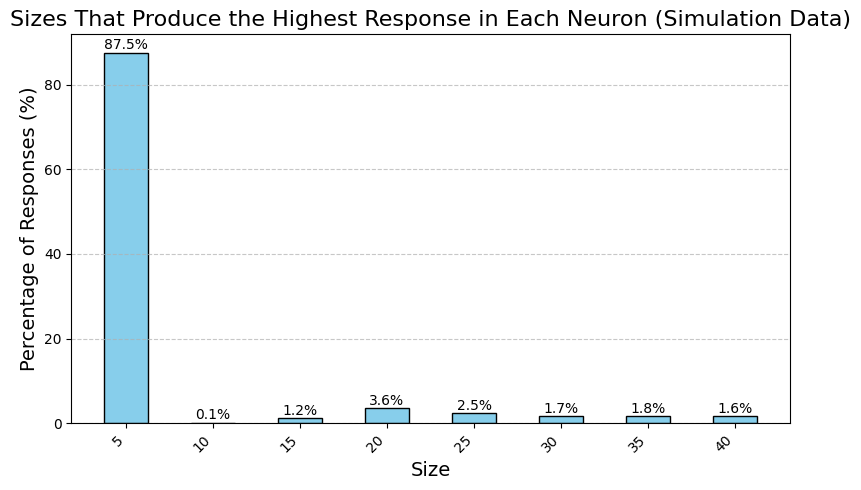

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
responses = highest_responses
sizes = corresponding_sizes  # Corresponding sizes for each response

# Count occurrences of each size
size_counts = {}
for size in sizes:
    if size in size_counts:
        size_counts[size] += 1
    else:
        size_counts[size] = 1

# Prepare data for plotting
size_values = list(size_counts.keys())
counts = list(size_counts.values())

# Calculate total counts for percentage conversion
total_count = sum(counts)
percentages = [(count / total_count) * 100 for count in counts]

# Sort size values and corresponding percentages
sorted_indices = np.argsort(size_values)
size_values = np.array(size_values)[sorted_indices]
percentages = np.array(percentages)[sorted_indices]

# Create a larger figure for better visibility
plt.figure(figsize=(8,5))

# Create the histogram with adjusted bar width
bar_width = 2.5  # Adjust the bar width as needed
plt.bar(size_values, percentages, width=bar_width, color='skyblue', edgecolor='black')

# Set labels and title
plt.xlabel('Size', fontsize=14)
plt.ylabel('Percentage of Responses (%)', fontsize=14)
plt.title('Sizes That Produce the Highest Response in Each Neuron (Simulation Data)', fontsize=16)

# Improve x-tick labeling
plt.xticks(size_values, rotation=45, ha='right')  # Rotate x-tick labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with percentages, adjusting the position of text for clarity
for i, percentage in enumerate(percentages):
    plt.text(size_values[i], percentage + 0.1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10)  # Add text above each bar

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()


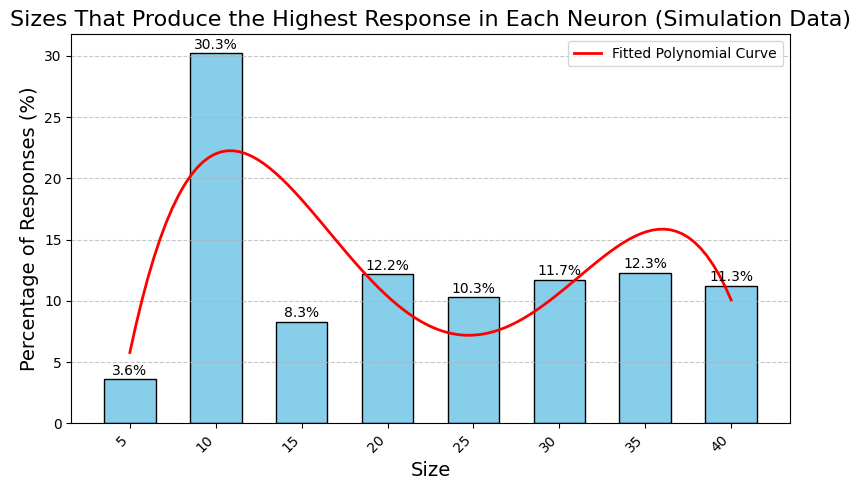

Polynomial coefficients: [-4.64964292e-04  4.43704602e-02 -1.44023139e+00  1.79574813e+01
 -5.32517935e+01]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace these with your actual data)
max_values = highest_responses
corr_sizes = corresponding_sizes  #

# Count occurrences of each size
size_counts = {}
for size in corr_sizes:
    if size in size_counts:
        size_counts[size] += 1
    else:
        size_counts[size] = 1

# Prepare data for plotting
size_values = list(size_counts.keys())
counts = list(size_counts.values())

# Calculate total counts for percentage conversion
total_count = sum(counts)
percentages = [(count / total_count) * 100 for count in counts]

# Sort size values and corresponding percentages
size_values = np.array(size_values, dtype=int)
sorted_indices = np.argsort(size_values)
size_values = np.array(size_values)[sorted_indices]
percentages = np.array(percentages)[sorted_indices]

# Create a larger figure for better visibility
plt.figure(figsize=(8, 5))

# Create the histogram with adjusted bar width
bar_width = 3.0  # Adjust the bar width as needed
plt.bar(size_values, percentages, width=bar_width, color='skyblue', edgecolor='black')

# Set labels and title
plt.xlabel('Size', fontsize=14)
plt.ylabel('Percentage of Responses (%)', fontsize=14)
plt.title('Sizes That Produce the Highest Response in Each Neuron (Simulation Data)', fontsize=16)

# Improve x-tick labeling
plt.xticks(size_values, rotation=45, ha='right')  # Rotate x-tick labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with percentages, adjusting the position of text for clarity
for i, percentage in enumerate(percentages):
    plt.text(size_values[i], percentage + 0.1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10)  # Add text above each bar

# Fit a polynomial curve (e.g., quadratic)
degree = 4  # You can adjust the degree of the polynomial
coeffs = np.polyfit(size_values, percentages, degree)

# Generate values for the fitted polynomial
x_fit = np.linspace(min(size_values), max(size_values), 100)
poly_fit = np.polyval(coeffs, x_fit)

# Plot the polynomial fit
plt.plot(x_fit, poly_fit, color='red', label='Fitted Polynomial Curve', linewidth=2)

# Show legend and plot
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

# Print polynomial coefficients
print("Polynomial coefficients:", coeffs)


In [ ]:
import pandas as pd

In [ ]:
orientation_data = pd.read_csv("Fitzpatrick_Data.csv")

In [ ]:
orientation_data

,5,10,15,20,25,30,35,40
0,0.043387,0.127410,0.244283,0.109346,0.076332,0.027591,0.066089,0.037460
1,0.045245,0.048591,0.068546,0.072787,0.012017,0.030030,0.076047,0.045700
2,0.080957,0.125833,0.141149,0.056454,0.094636,0.074085,0.061725,0.090849
3,0.038613,0.033998,0.118261,0.056834,0.059554,0.094410,0.084842,0.077075
4,0.124830,0.070462,0.164605,0.127014,0.087391,0.081534,0.047784,0.059621
...,...,...,...,...,...,...,...,...
2587,0.061517,0.099368,0.102558,0.020858,0.123983,0.042410,0.157641,0.064596
2588,0.034097,0.084532,0.096653,0.065373,0.112453,0.029017,0.101855,0.041538
2589,0.101516,0.145434,0.163644,0.133652,0.156830,0.126007,0.133053,0.169972
2590,0.009500,0.087050,0.181015,0.188935,0.223449,0.145468,0.183530,0.116169


In [ ]:
# Assuming orientation_data is your DataFrame
max_values = []
corr_sizes = []

for index, row in orientation_data.iterrows():
  max_value = row.max()
  corr_size = row.idxmax()
  max_values.append(max_value)
  corr_sizes.append(corr_size)

# Now you have lists of maximum values and corresponding sizes
print("Maximum values:", max_values)
print("Corresponding sizes:", corr_sizes)


Maximum values: [0.2442830314, 0.07604738652, 0.1411487824, 0.1182607859, 0.1646050072, 0.1792955119, 0.203576432, 0.1008778577, 0.1656741667, 0.3213136019, 0.1814112268, 0.3396844381, 0.1316042114, 0.1387551159, 0.1337571656, 0.094085848, 0.08049799483, 0.496687578, 0.08553578513, 0.1094324525, 0.6205308666, 0.1058060564, 0.1297470204, 0.3457719511, 0.2461168466, 0.3112507354, 0.4577995665, 0.110899347, 0.1409910007, 0.219644722, 0.1762455398, 0.2407197917, 0.2832654183, 0.1544543013, 0.2047966142, 0.1436043162, 0.6113581771, 0.1185246843, 0.1088269743, 0.1526944532, 0.2781207271, 0.1910470896, 0.8573029066, 0.5304465947, 0.09650141517, 0.2064414175, 0.2721611482, 0.1072537375, 0.1085532773, 0.1498920839, 0.2299579939, 0.1984753721, 0.1177637368, 0.1660420278, 0.1131784272, 0.2420469014, 0.1123489901, 0.2282317225, 0.1610394628, 0.2089169744, 0.4253698627, 0.4802698962, 0.08486268492, 0.1581484891, 0.2642438522, 0.4447040289, 0.2927051374, 0.3708566656, 0.2757452573, 0.2138188558, 0.4

In [ ]:
len(corr_sizes)

2592

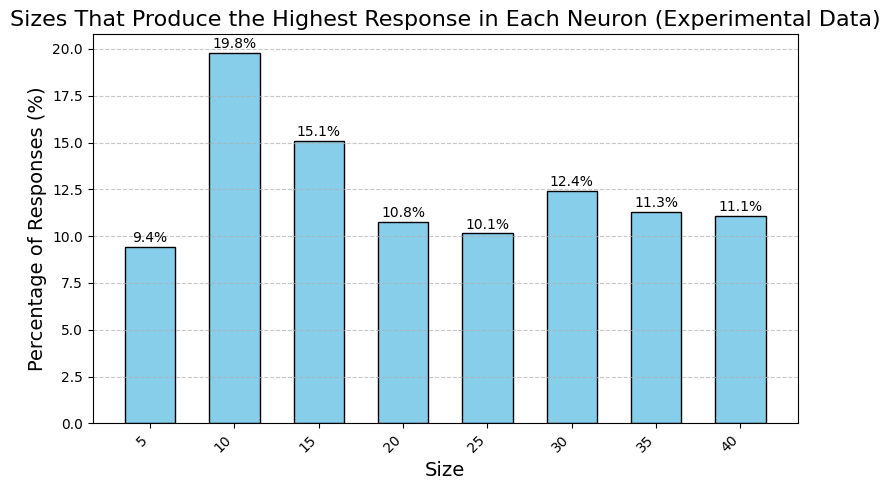

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Example data
responses = max_values
sizes = corr_sizes  # Corresponding sizes for each response

# Count occurrences of each size
size_counts = {}
for size in sizes:
    if size in size_counts:
        size_counts[size] += 1
    else:
        size_counts[size] = 1

# Prepare data for plotting
size_values = list(size_counts.keys())
counts = list(size_counts.values())

# Calculate total counts for percentage conversion
total_count = sum(counts)
percentages = [(count / total_count) * 100 for count in counts]

# Sort size values and corresponding percentages
size_values = np.array(size_values, dtype=int)
sorted_indices = np.argsort(size_values)
size_values = np.array(size_values)[sorted_indices]
percentages = np.array(percentages)[sorted_indices]

# Create a larger figure for better visibility
plt.figure(figsize=(8, 5))

# Create the histogram with adjusted bar width
bar_width = 3.0  # Adjust the bar width as needed
plt.bar(size_values, percentages, width=bar_width, color='skyblue', edgecolor='black')

# Set labels and title
plt.xlabel('Size', fontsize=14)
plt.ylabel('Percentage of Responses (%)', fontsize=14)
plt.title('Sizes That Produce the Highest Response in Each Neuron (Experimental Data)', fontsize=16)

# Improve x-tick labeling
plt.xticks(size_values, rotation=45, ha='right')  # Rotate x-tick labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with percentages, adjusting the position of text for clarity
for i, percentage in enumerate(percentages):
    plt.text(size_values[i], percentage + 0.1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10)  # Add text above each bar

# Show the plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

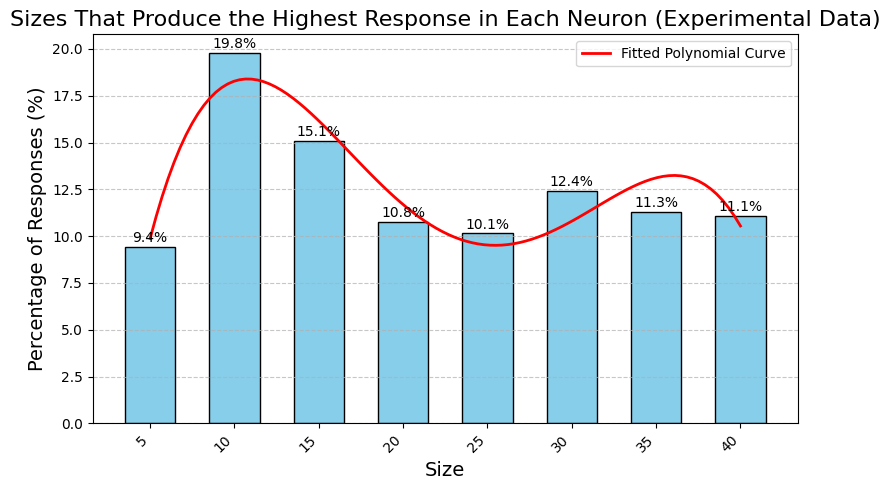

Polynomial coefficients: [-2.35105686e-04  2.26653105e-02 -7.43619646e-01  9.30985199e+00
 -2.07658179e+01]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Count occurrences of each size
size_counts = {}
for size in corr_sizes:
    if size in size_counts:
        size_counts[size] += 1
    else:
        size_counts[size] = 1

# Prepare data for plotting
size_values = list(size_counts.keys())
counts = list(size_counts.values())

# Calculate total counts for percentage conversion
total_count = sum(counts)
percentages = [(count / total_count) * 100 for count in counts]

# Sort size values and corresponding percentages
size_values = np.array(size_values, dtype=int)
sorted_indices = np.argsort(size_values)
size_values = np.array(size_values)[sorted_indices]
percentages = np.array(percentages)[sorted_indices]

# Create a larger figure for better visibility
plt.figure(figsize=(8, 5))

# Create the histogram with adjusted bar width
bar_width = 3.0  # Adjust the bar width as needed
plt.bar(size_values, percentages, width=bar_width, color='skyblue', edgecolor='black')

# Set labels and title
plt.xlabel('Size', fontsize=14)
plt.ylabel('Percentage of Responses (%)', fontsize=14)
plt.title('Sizes That Produce the Highest Response in Each Neuron (Experimental Data)', fontsize=16)

# Improve x-tick labeling
plt.xticks(size_values, rotation=45, ha='right')  # Rotate x-tick labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with percentages, adjusting the position of text for clarity
for i, percentage in enumerate(percentages):
    plt.text(size_values[i], percentage + 0.1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10)  # Add text above each bar

# Fit a polynomial curve (e.g., quadratic)
degree = 4 # You can adjust the degree of the polynomial
coeffs = np.polyfit(size_values, percentages, degree)

# Generate values for the fitted polynomial
x_fit = np.linspace(min(size_values), max(size_values), 100)
poly_fit = np.polyval(coeffs, x_fit)

# Plot the polynomial fit
plt.plot(x_fit, poly_fit, color='red', label='Fitted Polynomial Curve', linewidth=2)

# Show legend and plot
plt.legend()
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

# Print polynomial coefficients
print("Polynomial coefficients:", coeffs)


### Function for Finding MSE with Same Method

In [ ]:
def findMSE(Responses1, Sizes1, Responses2, Sizes2):

  max_values_1 = Responses1
  corr_sizes_1 = Sizes1

  # Count occurrences of each size for the first set
  size_counts_1 = {}
  for size in corr_sizes_1:
    if size in size_counts_1:
        size_counts_1[size] += 1
    else:
        size_counts_1[size] = 1

  # Prepare data for the first set
  size_values_1 = list(size_counts_1.keys())
  counts_1 = list(size_counts_1.values())

  # Calculate total counts for percentage conversion for the first set
  total_count_1 = sum(counts_1)
  percentages_1 = [(count / total_count_1) * 100 for count in counts_1]

  # Sort size values and corresponding percentages for the first set
  size_values_1 = np.array(size_values_1, dtype=int)
  sorted_indices_1 = np.argsort(size_values_1)
  size_values_1 = np.array(size_values_1)[sorted_indices_1]
  percentages_1 = np.array(percentages_1)[sorted_indices_1]

  # Fit a polynomial curve (e.g., quadratic) for the first set
  degree_1 = 2  # You can adjust the degree of the polynomial
  coeffs_1 = np.polyfit(size_values_1, percentages_1, degree_1)

  # Example data for the second set (replace with your actual data)
  max_values_2 = Responses2
  corr_sizes_2 = Sizes2

  # Count occurrences of each size for the second set
  size_counts_2 = {}
  for size in corr_sizes_2:
      if size in size_counts_2:
          size_counts_2[size] += 1
      else:
          size_counts_2[size] = 1

  # Prepare data for the second set
  size_values_2 = list(size_counts_2.keys())
  counts_2 = list(size_counts_2.values())

  # Calculate total counts for percentage conversion for the second set
  total_count_2 = sum(counts_2)
  percentages_2 = [(count / total_count_2) * 100 for count in counts_2]

  # Sort size values and corresponding percentages for the second set
  size_values_2 = np.array(size_values_2, dtype=int)
  sorted_indices_2 = np.argsort(size_values_2)
  size_values_2 = np.array(size_values_2)[sorted_indices_2]
  percentages_2 = np.array(percentages_2)[sorted_indices_2]

  # Fit a polynomial curve (e.g., quadratic) for the second set
  degree_2 = 2  # You can adjust the degree of the polynomial
  coeffs_2 = np.polyfit(size_values_2, percentages_2, degree_2)

  # Generate common x values for predictions
  x_common = np.linspace(min(min(size_values_1), min(size_values_2)),
                        max(max(size_values_1), max(size_values_2)),
                        100)

  # Evaluate both polynomials at the common x values
  predictions_1 = np.polyval(coeffs_1, x_common)
  predictions_2 = np.polyval(coeffs_2, x_common)

  # Calculate squared differences
  squared_diffs = (predictions_1 - predictions_2) ** 2

  # Compute MSE
  mse = np.mean(squared_diffs)

  print("Mean Squared Error (MSE) between the two polynomial fits:", mse)


In [ ]:
findMSE(highest_responses, corresponding_sizes, max_values, corr_sizes)

Mean Squared Error (MSE) between the two polynomial fits: 372.12817449147195
